# Round 1 Price Analysis — INTARIAN_PEPPER_ROOT & ASH_COATED_OSMIUM

In [1]:
import csv
import pandas as pd
import matplotlib.pyplot as plt

ROUND_NUM = 2
BASE = f'../imc-prosperity-4-backtester/prosperity4bt/resources/round{ROUND_NUM}'
BASE = '.'
DAYS = ['-1', '0', '1']


ipr_x, ipr_y = [], []
aco_x, aco_y = [], []
offset = 0

trades_frames = []

for day in DAYS:
    with open(f'{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            ts = offset + int(row['timestamp'])
            if row['product'] == 'INTARIAN_PEPPER_ROOT':
                ipr_x.append(ts); ipr_y.append(float(mid))
            elif row['product'] == 'ASH_COATED_OSMIUM':
                aco_x.append(ts); aco_y.append(float(mid))

    df = pd.read_csv(f'{BASE}/trades_round_{ROUND_NUM}_day_{day}.csv', delimiter=';')
    df['timestamp'] = df['timestamp'] + offset
    trades_frames.append(df)

    offset += 1_000_000

trades = pd.concat(trades_frames, ignore_index=True)
trades['price'] = trades['price'].astype(float)

ipr_trades = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT']
aco_trades = trades[trades['symbol'] == 'ASH_COATED_OSMIUM']

print(f'IPR ticks: {len(ipr_x)}  |  ACO ticks: {len(aco_x)}')
print(f'IPR range: {min(ipr_y):.1f} – {max(ipr_y):.1f}')
print(f'ACO range: {min(aco_y):.1f} – {max(aco_y):.1f}')
print(f'IPR trades: {len(ipr_trades)}  |  ACO trades: {len(aco_trades)}')

IPR ticks: 29953  |  ACO ticks: 29947
IPR range: 10998.0 – 14003.0
ACO range: 9979.0 – 10023.0
IPR trades: 996  |  ACO trades: 1395


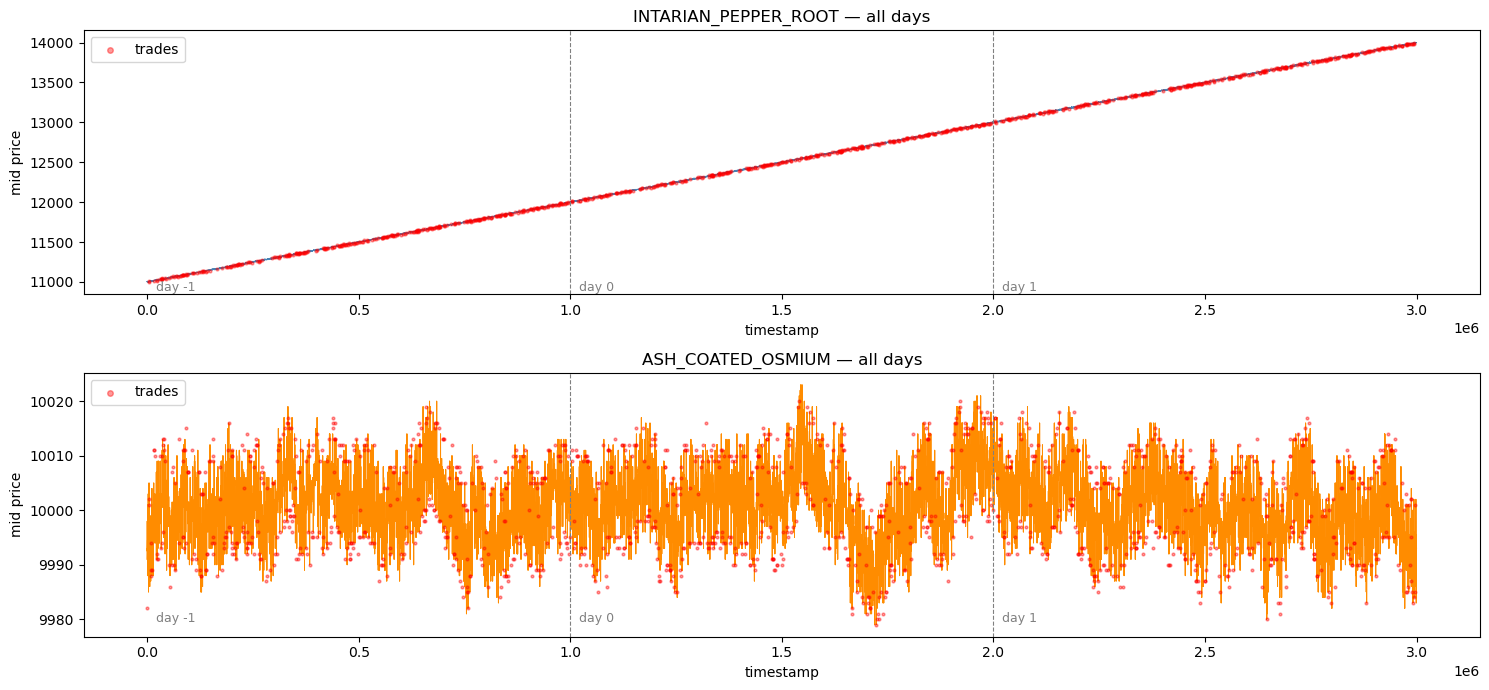

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=False)

ax1.plot(ipr_x, ipr_y, lw=0.7, color='steelblue', zorder=1)
ax1.scatter(ipr_trades['timestamp'], ipr_trades['price'], s=4, color='red', alpha=0.4, zorder=2, label='trades')
ax1.set_title('INTARIAN_PEPPER_ROOT — all days')
ax1.set_ylabel('mid price')
ax1.set_xlabel('timestamp')
ax1.legend(loc='upper left', markerscale=2)
for sep in [1_000_000, 2_000_000]:
    ax1.axvline(sep, color='gray', lw=0.8, ls='--')
for i, label in enumerate(['day -1', 'day 0', 'day 1']):
    ax1.text(i * 1_000_000 + 20_000, ax1.get_ylim()[0] if ax1.get_ylim()[0] != 0 else min(ipr_y),
             label, fontsize=9, color='gray', va='bottom')

ax2.plot(aco_x, aco_y, lw=0.7, color='darkorange', zorder=1)
ax2.plot(aco_x, aco_y, lw=0.7, color='darkorange', zorder=1)
ax2.scatter(aco_trades['timestamp'], aco_trades['price'], s=4, color='red', alpha=0.4, zorder=2, label='trades')
ax2.set_title('ASH_COATED_OSMIUM — all days')
ax2.set_ylabel('mid price')
ax2.set_xlabel('timestamp')
ax2.legend(loc='upper left', markerscale=2)
for sep in [1_000_000, 2_000_000]:
    ax2.axvline(sep, color='gray', lw=0.8, ls='--')
for i, label in enumerate(['day -1', 'day 0', 'day 1']):
    ax2.text(i * 1_000_000 + 20_000, min(aco_y), label, fontsize=9, color='gray', va='bottom')

plt.tight_layout()
plt.show()

INTARIAN_PEPPER_ROOT
  n trades      : 996
  mean interarr : 3020.91 ticks
  lambda (MLE)  : 0.000331 trades/tick
ASH_COATED_OSMIUM
  n trades      : 1395
  mean interarr : 2178.20 ticks
  lambda (MLE)  : 0.000459 trades/tick


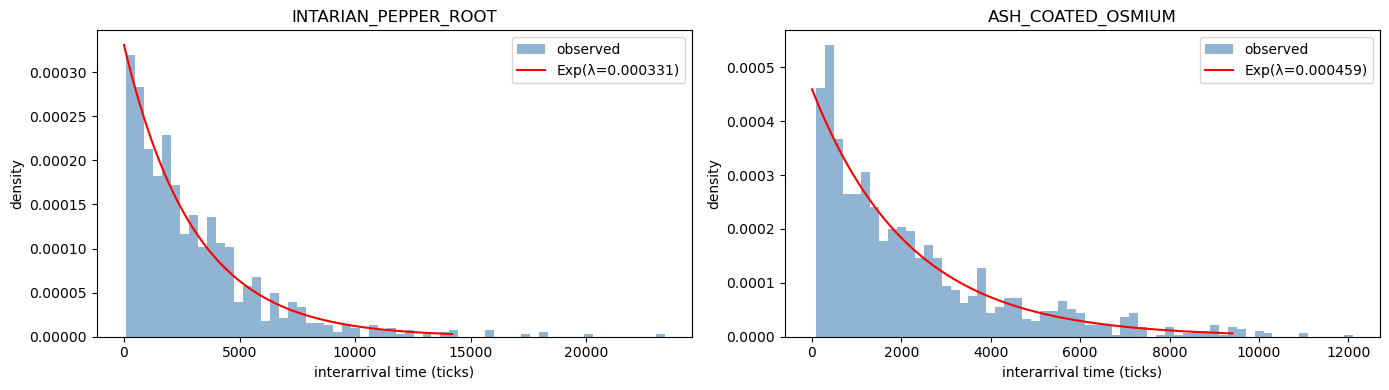

In [3]:
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, label in [
    (axes[0], ipr_trades, 'INTARIAN_PEPPER_ROOT'),
    (axes[1], aco_trades, 'ASH_COATED_OSMIUM'),
]:
    ts = df['timestamp'].sort_values().values
    interarrivals = np.diff(ts).astype(float)
    interarrivals = interarrivals[interarrivals > 0]  # drop same-tick duplicates

    lam = 1.0 / interarrivals.mean()

    x = np.linspace(0, np.percentile(interarrivals, 99), 500)
    ax.hist(interarrivals, bins=60, density=True, color='steelblue', alpha=0.6, label='observed')
    ax.plot(x, stats.expon.pdf(x, scale=1/lam), color='red', lw=1.5, label=f'Exp(λ={lam:.6f})')
    ax.set_title(label)
    ax.set_xlabel('interarrival time (ticks)')
    ax.set_ylabel('density')
    ax.legend()
    print(f'{label}')
    print(f'  n trades      : {len(ts)}')
    print(f'  mean interarr : {interarrivals.mean():.2f} ticks')
    print(f'  lambda (MLE)  : {lam:.6f} trades/tick')

plt.tight_layout()
plt.show()

In [4]:

# Statistical tests for exponential fit and memoryless property (p=0.05)
#
# 1. Kolmogorov-Smirnov test  — one-sample, against Exp(lambda_MLE)
# 2. Anderson-Darling test    — heavier tail sensitivity than KS
# 3. Memoryless property test — two-sample KS: (X - s | X > s) vs X
#    Under the memoryless property P(X > s+t | X > s) = P(X > t),
#    so the excess life distribution must match the original.

ALPHA = 0.05
MEMORYLESS_THRESHOLD_QUANTILE = 0.5   # use median as the conditioning threshold s

datasets = [
    ('INTARIAN_PEPPER_ROOT', ipr_trades),
    ('ASH_COATED_OSMIUM',    aco_trades),
]

for label, df in datasets:
    ts = df['timestamp'].sort_values().values
    ia = np.diff(ts).astype(float)
    ia = ia[ia > 0]

    lam = 1.0 / ia.mean()
    n   = len(ia)

    print(f'=== {label}  (n={n}) ===')

    # ------------------------------------------------------------------
    # 1. KS test against Exp(lambda_MLE)
    # ------------------------------------------------------------------
    ks_stat, ks_p = stats.kstest(ia, 'expon', args=(0, 1.0 / lam))
    ks_pass = ks_p >= ALPHA
    print(f'  KS test        stat={ks_stat:.4f}  p={ks_p:.4f}  {"PASS" if ks_pass else "FAIL"} (reject H0 = not exponential)')

    # ------------------------------------------------------------------
    # 2. Anderson-Darling test for exponential
    #    scipy returns critical values at [15%, 10%, 5%, 2.5%, 1%]
    # ------------------------------------------------------------------
    ad_result = stats.anderson(ia, dist='expon')
    # index 2 corresponds to 5% significance level
    ad_stat  = ad_result.statistic
    ad_crit5 = ad_result.critical_values[2]
    ad_pass  = ad_stat <= ad_crit5
    print(f'  AD test        stat={ad_stat:.4f}  crit(5%)={ad_crit5:.4f}  {"PASS" if ad_pass else "FAIL"} (reject H0 = not exponential)')

    # ------------------------------------------------------------------
    # 3. Memoryless property test
    #    Condition on X > s, shift by s, compare to original via 2-sample KS.
    #    H0: excess-life distribution == original distribution.
    # ------------------------------------------------------------------
    s = np.quantile(ia, MEMORYLESS_THRESHOLD_QUANTILE)
    excess = ia[ia > s] - s
    ml_stat, ml_p = stats.ks_2samp(ia, excess)
    ml_pass = ml_p >= ALPHA
    print(f'  Memoryless KS  stat={ml_stat:.4f}  p={ml_p:.4f}  {"PASS" if ml_pass else "FAIL"} (reject H0 = not memoryless)  [s={s:.0f} ticks, n_excess={len(excess)}]')

    print()


=== INTARIAN_PEPPER_ROOT  (n=990) ===
  KS test        stat=0.0446  p=0.0376  FAIL (reject H0 = not exponential)
  AD test        stat=2.2979  crit(5%)=1.3400  FAIL (reject H0 = not exponential)
  Memoryless KS  stat=0.0746  p=0.0494  FAIL (reject H0 = not memoryless)  [s=2200 ticks, n_excess=487]

=== ASH_COATED_OSMIUM  (n=1376) ===
  KS test        stat=0.0449  p=0.0076  FAIL (reject H0 = not exponential)
  AD test        stat=2.7928  crit(5%)=1.3400  FAIL (reject H0 = not exponential)
  Memoryless KS  stat=0.0449  p=0.3062  PASS (reject H0 = not memoryless)  [s=1500 ticks, n_excess=680]



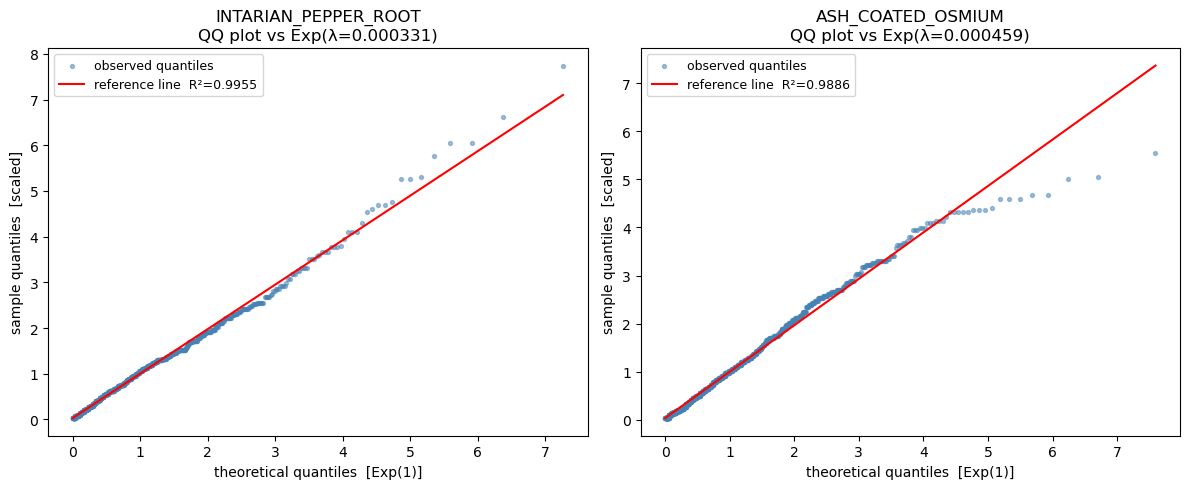

In [5]:

# QQ plots: observed interarrival quantiles vs theoretical Exp(lambda_MLE)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, label in [
    (axes[0], ipr_trades, 'INTARIAN_PEPPER_ROOT'),
    (axes[1], aco_trades, 'ASH_COATED_OSMIUM'),
]:
    ts = df['timestamp'].sort_values().values
    ia = np.diff(ts).astype(float)
    ia = ia[ia > 0]

    # Scale to unit exponential so probplot reference line is y=x
    lam = 1.0 / ia.mean()
    ia_scaled = ia * lam

    (osm, osr), (slope, intercept, r) = stats.probplot(ia_scaled, dist='expon', fit=True)

    ax.scatter(osm, osr, s=8, alpha=0.5, color='steelblue', label='observed quantiles')
    ax.plot(osm, slope * osm + intercept, color='red', lw=1.5, label=f'reference line  R²={r**2:.4f}')
    ax.set_title(f'{label}\nQQ plot vs Exp(λ={lam:.6f})')
    ax.set_xlabel('theoretical quantiles  [Exp(1)]')
    ax.set_ylabel('sample quantiles  [scaled]')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


slope        : 0.000999  price/tick
lambda (IPR) : 0.000331  trades/tick
E[wait]      : 3020.91  ticks
min spread   : 3.0190  (= slope / lambda)


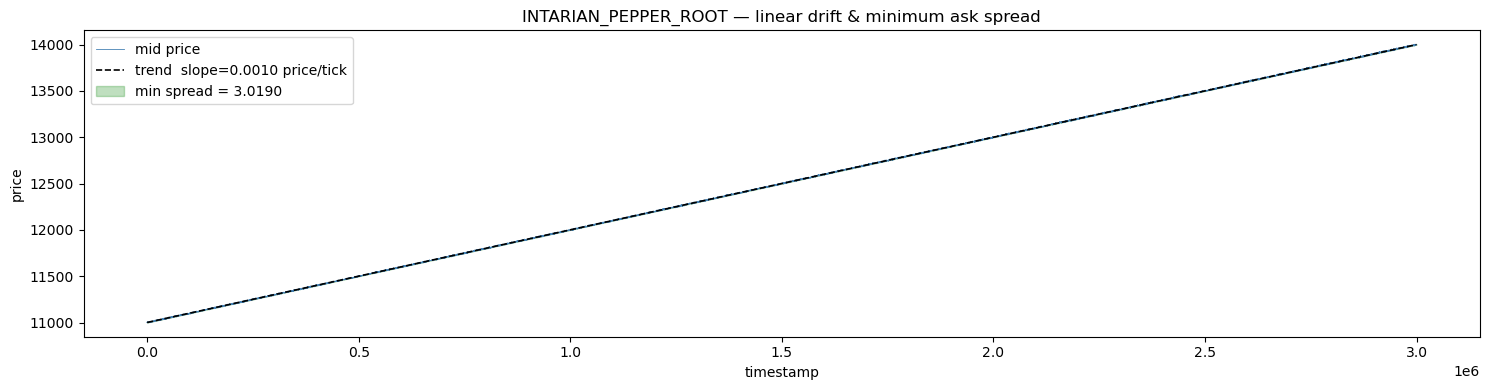

In [6]:
# --- 1. slope via two-point regression (first and last mid price) ---
ipr_x_arr = np.array(ipr_x)
ipr_y_arr = np.array(ipr_y)

t0, t1 = ipr_x_arr[0],  ipr_x_arr[-1]
p0, p1 = ipr_y_arr[0],  ipr_y_arr[-1]
slope = (p1 - p0) / (t1 - t0)          # price / tick

trend_y = p0 + slope * (ipr_x_arr - t0)

# --- 2. lambda for IPR interarrivals (reuse logic from previous cell) ---
ipr_ts = ipr_trades['timestamp'].sort_values().values
ipr_ia = np.diff(ipr_ts).astype(float)
ipr_ia = ipr_ia[ipr_ia > 0]
lam_ipr = 1.0 / ipr_ia.mean()          # trades / tick

# --- 3. minimum ask offset ---
# While waiting E[T] = 1/λ ticks for a fill, the fair value drifts up by slope/λ.
# Quoting at ask = mid + spread beats holding only when:
#   spread  >  slope / λ
min_spread = slope / lam_ipr            # ticks above mid

print(f'slope        : {slope:.6f}  price/tick')
print(f'lambda (IPR) : {lam_ipr:.6f}  trades/tick')
print(f'E[wait]      : {1/lam_ipr:.2f}  ticks')
print(f'min spread   : {min_spread:.4f}  (= slope / lambda)')

# --- 4. plot ---
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(ipr_x_arr, ipr_y_arr, lw=0.6, color='steelblue', label='mid price')
ax.plot(ipr_x_arr, trend_y, lw=1.2, color='black', ls='--',
        label=f'trend  slope={slope:.4f} price/tick')
ax.set_title('INTARIAN_PEPPER_ROOT — linear drift & minimum ask spread')
ax.set_xlabel('timestamp')
ax.set_ylabel('price')

# shade the minimum spread band above the trend line
ax.fill_between(ipr_x_arr, trend_y, trend_y + min_spread,
                alpha=0.25, color='green',
                label=f'min spread = {min_spread:.4f}')

ax.legend()
plt.tight_layout()
plt.show()

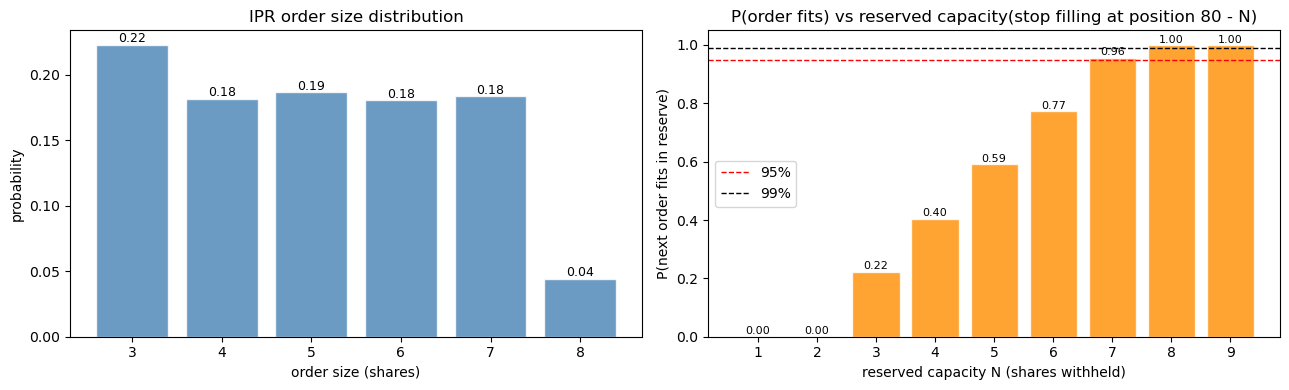

median order size : 5 shares
max order size    : 8 shares
to cover 95% of orders, reserve >= 7 shares  (fill limit: 73)
to cover 99% of orders, reserve >= 8 shares  (fill limit: 72)


In [7]:
# IPR order size distribution & inventory buffer analysis
# POS_LIMIT from template.py
POS_LIMIT = 80

qtys = ipr_trades['quantity'].values

sizes, counts = np.unique(qtys, return_counts=True)
probs = counts / counts.sum()
cdf = np.cumsum(probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# --- left: order size PMF ---
ax1.bar(sizes, probs, color='steelblue', alpha=0.8, edgecolor='white')
ax1.set_title('IPR order size distribution')
ax1.set_xlabel('order size (shares)')
ax1.set_ylabel('probability')
ax1.set_xticks(sizes)
for s, p in zip(sizes, probs):
    ax1.text(s, p + 0.002, f'{p:.2f}', ha='center', fontsize=9)

# --- right: P(order fits in buffer) vs reserved capacity ---
# If we keep N shares of capacity reserved (i.e. stop filling at POS_LIMIT - N),
# P(next order fits entirely in that buffer) = P(order_size <= N) = CDF(N)
buf_range = np.arange(1, sizes.max() + 2)
p_fits = np.array([np.mean(qtys <= n) for n in buf_range])

ax2.bar(buf_range, p_fits, color='darkorange', alpha=0.8, edgecolor='white')
ax2.set_title(f'P(order fits) vs reserved capacity(stop filling at position {POS_LIMIT} - N)')
ax2.set_xlabel('reserved capacity N (shares withheld)')
ax2.set_ylabel('P(next order fits in reserve)')
ax2.set_xticks(buf_range)
ax2.axhline(0.95, color='red', lw=1, ls='--', label='95%')
ax2.axhline(0.99, color='black', lw=1, ls='--', label='99%')
ax2.legend()
for n, p in zip(buf_range, p_fits):
    ax2.text(n, p + 0.008, f'{p:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'median order size : {int(np.median(qtys))} shares')
print(f'max order size    : {int(qtys.max())} shares')
print(f'to cover 95% of orders, reserve >= {buf_range[p_fits >= 0.95][0]} shares  (fill limit: {POS_LIMIT - buf_range[p_fits >= 0.95][0]})')
print(f'to cover 99% of orders, reserve >= {buf_range[p_fits >= 0.99][0]} shares  (fill limit: {POS_LIMIT - buf_range[p_fits >= 0.99][0]})')

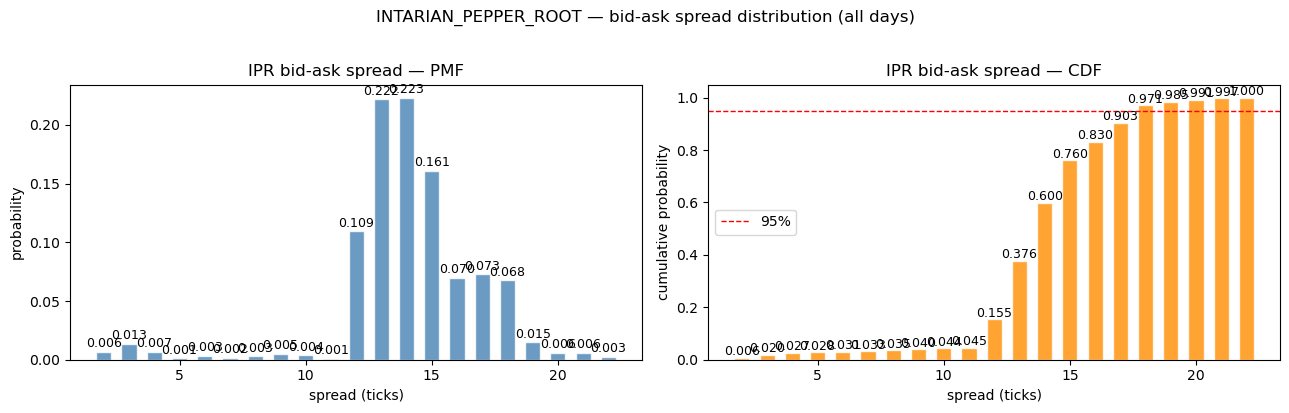

ticks with valid spread : 27724
mean spread  : 14.12
median spread: 14.0
min spread   : 2.0
max spread   : 22.0
  spread=2  prob=0.0064  cdf=0.0064
  spread=3  prob=0.0133  cdf=0.0197
  spread=4  prob=0.0069  cdf=0.0267
  spread=5  prob=0.0013  cdf=0.0280
  spread=6  prob=0.0030  cdf=0.0310
  spread=7  prob=0.0017  cdf=0.0327
  spread=8  prob=0.0028  cdf=0.0355
  spread=9  prob=0.0048  cdf=0.0403
  spread=10  prob=0.0038  cdf=0.0441
  spread=11  prob=0.0010  cdf=0.0451
  spread=12  prob=0.1095  cdf=0.1546
  spread=13  prob=0.2219  cdf=0.3765
  spread=14  prob=0.2232  cdf=0.5997
  spread=15  prob=0.1608  cdf=0.7605
  spread=16  prob=0.0698  cdf=0.8303
  spread=17  prob=0.0727  cdf=0.9030
  spread=18  prob=0.0676  cdf=0.9705
  spread=19  prob=0.0147  cdf=0.9852
  spread=20  prob=0.0061  cdf=0.9913
  spread=21  prob=0.0060  cdf=0.9973
  spread=22  prob=0.0027  cdf=1.0000


In [8]:
# IPR bid-ask spread distribution
spreads = []

for day in DAYS:
    with open(f'{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            if row['product'] != 'INTARIAN_PEPPER_ROOT':
                continue
            bid = row['bid_price_1']
            ask = row['ask_price_1']
            if bid and ask:
                spreads.append(float(ask) - float(bid))

spreads = np.array(spreads)

vals, counts = np.unique(spreads, return_counts=True)
probs = counts / counts.sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(vals, probs, width=0.6, color='steelblue', alpha=0.8, edgecolor='white')
ax1.set_title('IPR bid-ask spread — PMF')
ax1.set_xlabel('spread (ticks)')
ax1.set_ylabel('probability')
for v, p in zip(vals, probs):
    ax1.text(v, p + 0.004, f'{p:.3f}', ha='center', fontsize=9)

ax2.bar(vals, np.cumsum(probs), width=0.6, color='darkorange', alpha=0.8, edgecolor='white')
ax2.set_title('IPR bid-ask spread — CDF')
ax2.set_xlabel('spread (ticks)')
ax2.set_ylabel('cumulative probability')
ax2.axhline(0.95, color='red', lw=1, ls='--', label='95%')
ax2.legend()
for v, c in zip(vals, np.cumsum(probs)):
    ax2.text(v, c + 0.01, f'{c:.3f}', ha='center', fontsize=9)

plt.suptitle('INTARIAN_PEPPER_ROOT — bid-ask spread distribution (all days)', y=1.02)
plt.tight_layout()
plt.show()

print(f'ticks with valid spread : {len(spreads)}')
print(f'mean spread  : {spreads.mean():.2f}')
print(f'median spread: {np.median(spreads):.1f}')
print(f'min spread   : {spreads.min():.1f}')
print(f'max spread   : {spreads.max():.1f}')
for v, p, c in zip(vals, probs, np.cumsum(probs)):
    print(f'  spread={v:.0f}  prob={p:.4f}  cdf={c:.4f}')


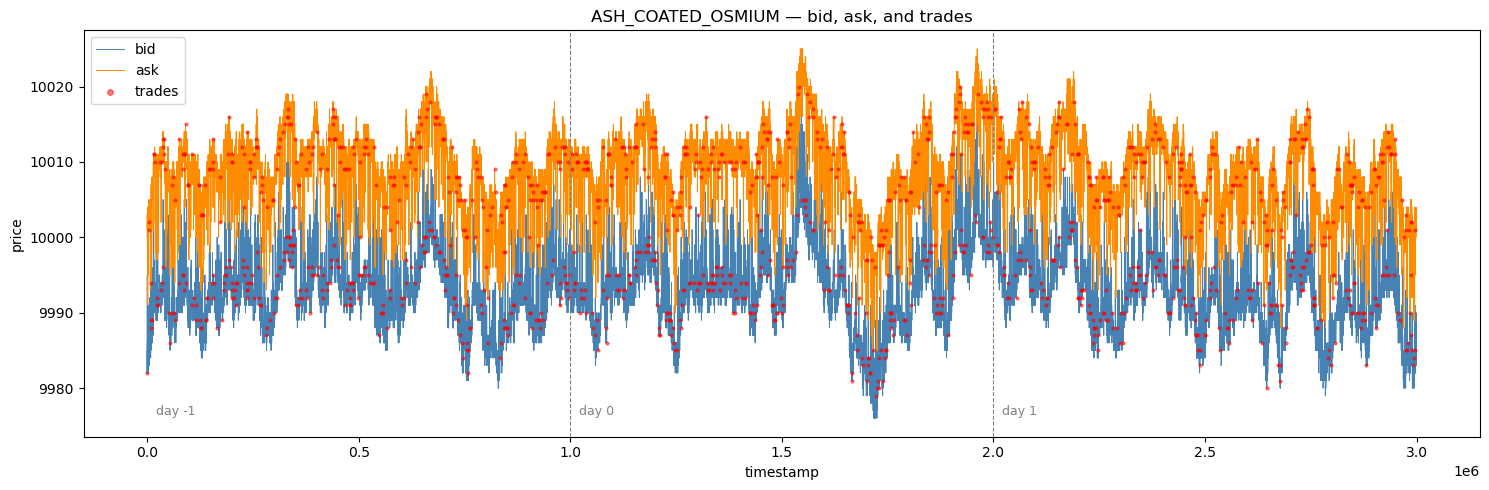

In [9]:
# ACO bid/ask over time with trades overlaid
aco_bid_x, aco_bid_y = [], []
aco_ask_x, aco_ask_y = [], []
offset = 0

for day in DAYS:
    with open(f'{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            if row['product'] != 'ASH_COATED_OSMIUM':
                continue
            bid = row['bid_price_1']
            ask = row['ask_price_1']
            ts = offset + int(row['timestamp'])
            if bid:
                aco_bid_x.append(ts); aco_bid_y.append(float(bid))
            if ask:
                aco_ask_x.append(ts); aco_ask_y.append(float(ask))
    offset += 1_000_000

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(aco_bid_x, aco_bid_y, lw=0.7, color='steelblue', label='bid', zorder=1)
ax.plot(aco_ask_x, aco_ask_y, lw=0.7, color='darkorange', label='ask', zorder=1)
ax.scatter(aco_trades['timestamp'], aco_trades['price'], s=4, color='red', alpha=0.5, zorder=2, label='trades')

for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='gray', lw=0.8, ls='--')
for i, label in enumerate(['day -1', 'day 0', 'day 1']):
    ax.text(i * 1_000_000 + 20_000, min(aco_bid_y), label, fontsize=9, color='gray', va='bottom')

ax.set_title('ASH_COATED_OSMIUM — bid, ask, and trades')
ax.set_xlabel('timestamp')
ax.set_ylabel('price')
ax.legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()


In [10]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

def plot_lob_heatmap(df_lob, df_trades):
    """
    df_lob: DataFrame with [timestamp, bid_1/2/3, ask_1/2/3, bid_size_1/2/3, ask_size_1/2/3]
    df_trades: DataFrame with [timestamp, price, quantity, side]
    """
    fig = go.Figure()

    # 1. Prepare Heatmap Data (Melting levels for visualization)
    # We create a scatter trace for each level where marker size/color represents volume
    levels = ['1', '2', '3']
    for level in levels:
        # Bids (Buy side) - often shades of green
        fig.add_trace(go.Scatter(
            x=df_lob['timestamp'], y=df_lob[f'bid_{level}'],
            mode='markers',
            marker=dict(size=5, color=df_lob[f'bid_size_{level}'], colorscale='Greens', showscale=False),
            name=f'Bid Level {level}',
            opacity=0.6
        ))
        # Asks (Sell side) - often shades of red
        fig.add_trace(go.Scatter(
            x=df_lob['timestamp'], y=df_lob[f'ask_{level}'],
            mode='markers',
            marker=dict(size=5, color=df_lob[f'ask_size_{level}'], colorscale='Reds', showscale=False),
            name=f'Ask Level {level}',
            opacity=0.6
        ))

    # 2. Overlay Bot Trades
    # Markers represent the bot's execution price and quantity
    fig.add_trace(go.Scatter(
        x=df_trades['timestamp'],
        y=df_trades['price'],
        mode='markers',
        marker=dict(
            symbol='x',
            size=df_trades['quantity'].clip(upper=20), # Scaling size by trade volume
            color='black',
            line=dict(width=1, color='white')
        ),
        name='Bot Trades'
    ))

    # 3. Layout Formatting
    fig.update_layout(
        title="LOB Heatmap with Bot Trade Overlay",
        xaxis_title="Timestamp",
        yaxis_title="Price",
        template="plotly_dark",
        hovermode="closest"
    )

    fig.show()

# Example usage:
# plot_lob_heatmap(your_lob_data, your_trade_data)

In [11]:
all_days_prices_2 = pd.DataFrame()
for day in DAYS:
    df = pd.read_csv(f"prices_round_{ROUND_NUM}_day_{day}.csv", sep=';')
    df.timestamp = df.timestamp + int(df.day - min(DAYS)) * 1_000_000
    all_days_prices_2 = pd.concat([all_days_prices_2, df], ignore_index=True)

ipr_prices = all_days_prices_2[all_days_prices_2['product'] == 'INTARIAN_PEPPER_ROOT']
aco_prices = all_days_prices_2[all_days_prices_2['product'] == 'ASH_COATED_OSMIUM']

UFuncTypeError: ufunc 'subtract' did not contain a loop with signature matching types (dtype('int64'), dtype('<U2')) -> None

0       -1000000
1       -1000000
2        -999900
3        -999900
4        -999800
          ...   
19995       -300
19996       -200
19997       -200
19998       -100
19999       -100
Length: 20000, dtype: int64

In [ ]:
all_days_prices_1 = pd.DataFrame()
for day in [-2,-1,0]:
    df = pd.read_csv(f"../ROUND1/prices_round_1_day_{day}.csv", sep=';')
    all_days_prices_1 = pd.concat([all_days_prices_1, df], ignore_index=True)

In [ ]:
print(all_days_prices_1[2_000_000//100 -2: 2_000_000//100 + 5])

       day  timestamp               product  bid_price_1  bid_volume_1  \
19998   -2     999900  INTARIAN_PEPPER_ROOT      10994.0           8.0   
19999   -2     999900     ASH_COATED_OSMIUM       9984.0          13.0   
20000   -1          0  INTARIAN_PEPPER_ROOT      10991.0          15.0   
20001   -1          0     ASH_COATED_OSMIUM          NaN           NaN   
20002   -1        100     ASH_COATED_OSMIUM       9984.0          11.0   
20003   -1        100  INTARIAN_PEPPER_ROOT      10994.0           9.0   
20004   -1        200     ASH_COATED_OSMIUM       9985.0          15.0   

       bid_price_2  bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  \
19998          NaN           NaN          NaN           NaN      11009.0   
19999          NaN           NaN          NaN           NaN      10003.0   
20000          NaN           NaN          NaN           NaN      11006.0   
20001          NaN           NaN          NaN           NaN      10003.0   
20002          NaN         

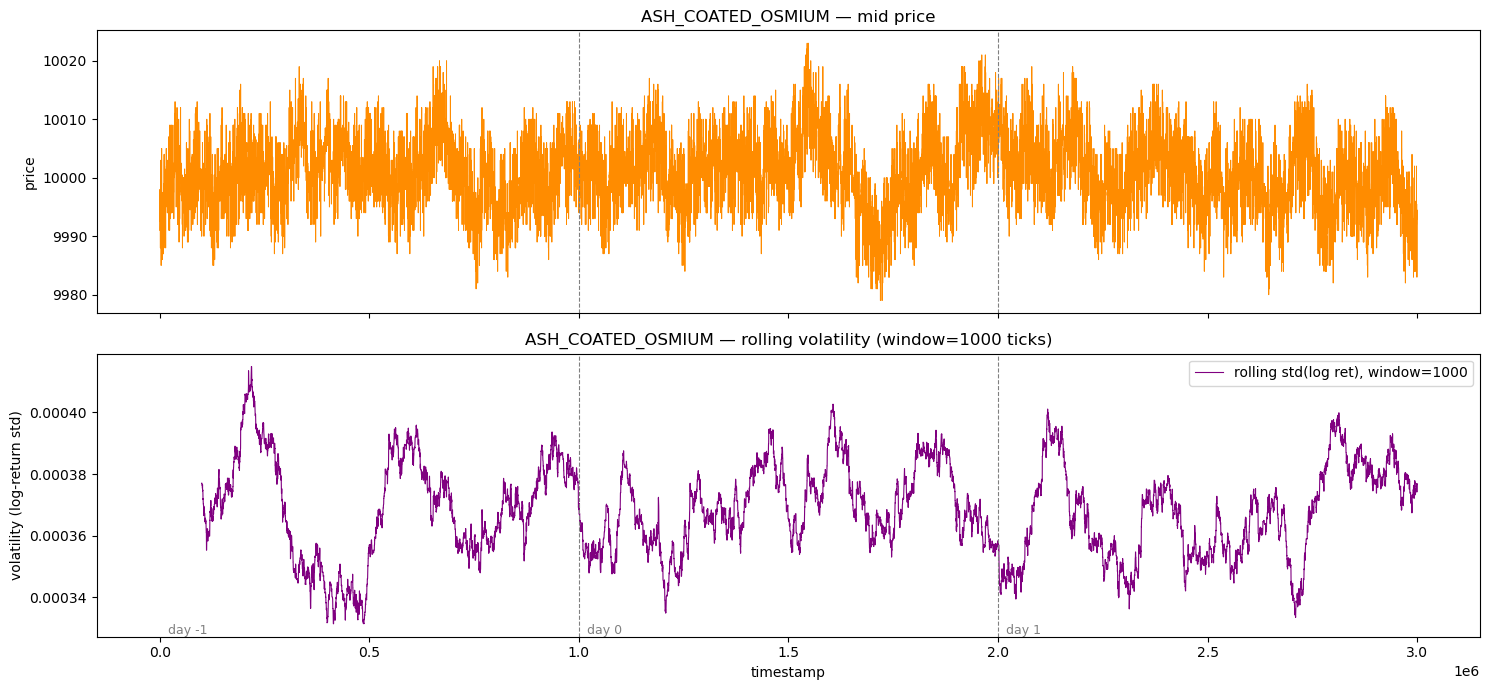

mean vol : 0.000368
max vol  : 0.000415
min vol  : 0.000331


In [13]:

# ASH_COATED_OSMIUM — rolling volatility (std of log returns)
WINDOW = 1000 # ticks

aco_arr = np.array(aco_y)
aco_ts  = np.array(aco_x)

log_ret = np.diff(np.log(aco_arr))
ret_ts  = aco_ts[1:]

# rolling std
roll_vol = pd.Series(log_ret).rolling(WINDOW, min_periods=WINDOW).std().values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

ax1.plot(aco_ts, aco_arr, lw=0.7, color='darkorange')
ax1.set_title('ASH_COATED_OSMIUM — mid price')
ax1.set_ylabel('price')
for sep in [1_000_000, 2_000_000]:
    ax1.axvline(sep, color='gray', lw=0.8, ls='--')

ax2.plot(ret_ts, roll_vol, lw=0.8, color='purple', label=f'rolling std(log ret), window={WINDOW}')
ax2.set_title(f'ASH_COATED_OSMIUM — rolling volatility (window={WINDOW} ticks)')
ax2.set_ylabel('volatility (log-return std)')
ax2.set_xlabel('timestamp')
for sep in [1_000_000, 2_000_000]:
    ax2.axvline(sep, color='gray', lw=0.8, ls='--')
for i, lbl in enumerate(['day -1', 'day 0', 'day 1']):
    ax2.text(i * 1_000_000 + 20_000, ax2.get_ylim()[0] if ax2.get_ylim()[0] else 0,
             lbl, fontsize=9, color='gray', va='bottom')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'mean vol : {np.nanmean(roll_vol):.6f}')
print(f'max vol  : {np.nanmax(roll_vol):.6f}')
print(f'min vol  : {np.nanmin(roll_vol):.6f}')
